# Lab 8: Visualization of Graph Data

1. Directed Graph Visualization

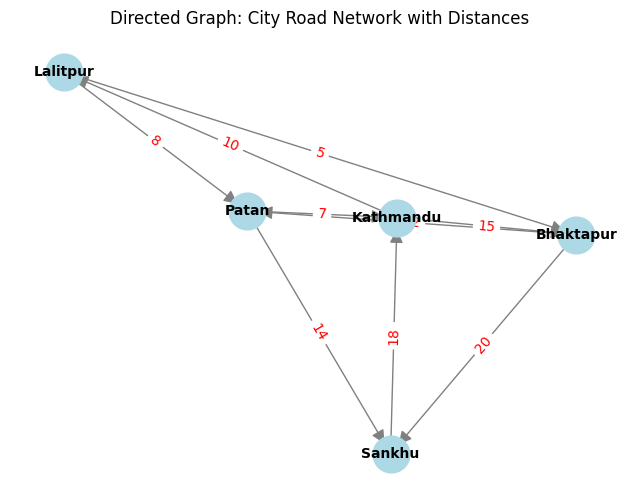

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create directed graph
G_directed = nx.DiGraph()

edges = [
    ("Kathmandu", "Lalitpur", 10),
    ("Kathmandu", "Bhaktapur", 15),
    ("Lalitpur", "Bhaktapur", 5),
    ("Bhaktapur", "Patan", 12),
    ("Patan", "Kathmandu", 7),
    ("Lalitpur", "Patan", 8),
    ("Bhaktapur", "Sankhu", 20),
    ("Sankhu", "Kathmandu", 18),
    ("Patan", "Sankhu", 14),
]

G_directed.add_weighted_edges_from(edges)

# Positions for all nodes
pos = nx.spring_layout(G_directed, seed=42)

plt.figure(figsize=(8,6))
nx.draw_networkx_nodes(G_directed, pos, node_color='lightblue', node_size=700)
nx.draw_networkx_labels(G_directed, pos, font_size=10, font_weight='bold')

# Draw edges with arrowheads and weights
nx.draw_networkx_edges(G_directed, pos, arrowstyle='-|>', arrowsize=20, edge_color='gray')
edge_labels = nx.get_edge_attributes(G_directed, 'weight')
nx.draw_networkx_edge_labels(G_directed, pos, edge_labels=edge_labels, font_color='red')

plt.title("Directed Graph: City Road Network with Distances")
plt.axis('off')
plt.show()


Dataset: Simulated 6-city road network with 9 directional roads and distances in kilometers.

Features: Node = City names; Edges = directed roads with weights = distance.

Observation: The graph shows directional roads between cities, e.g., Kathmandu → Lalitpur (10 km). Arrowheads help understand one-way travel

2. Undirected Graph Visualization

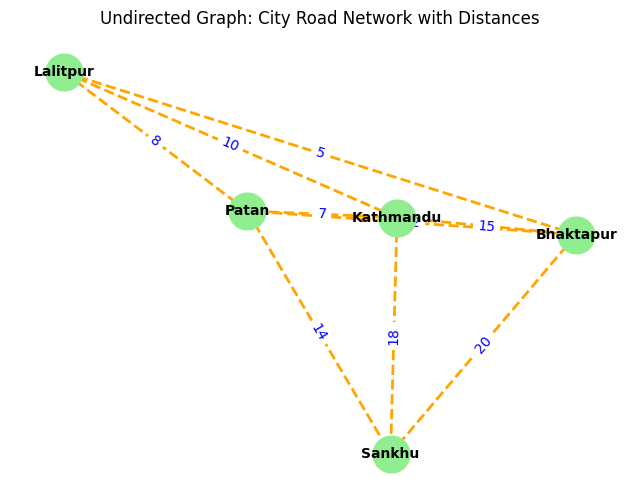

In [2]:
# Convert to undirected graph
G_undirected = G_directed.to_undirected()

plt.figure(figsize=(8,6))
nx.draw_networkx_nodes(G_undirected, pos, node_color='lightgreen', node_size=700)
nx.draw_networkx_labels(G_undirected, pos, font_size=10, font_weight='bold')

# Draw undirected edges with different style
nx.draw_networkx_edges(G_undirected, pos, edge_color='orange', width=2, style='dashed')

# Edge labels for weights
nx.draw_networkx_edge_labels(G_undirected, pos, edge_labels=edge_labels, font_color='blue')

plt.title("Undirected Graph: City Road Network with Distances")
plt.axis('off')
plt.show()


Dataset: Same cities and roads but now roads are bidirectional (undirected).

Features: Undirected edges with distances.

Observation: The dashed orange edges indicate bidirectional roads, no arrowheads, and the network looks symmetric.

3. Weighted Graph Visualization (Edge thickness + color intensity)

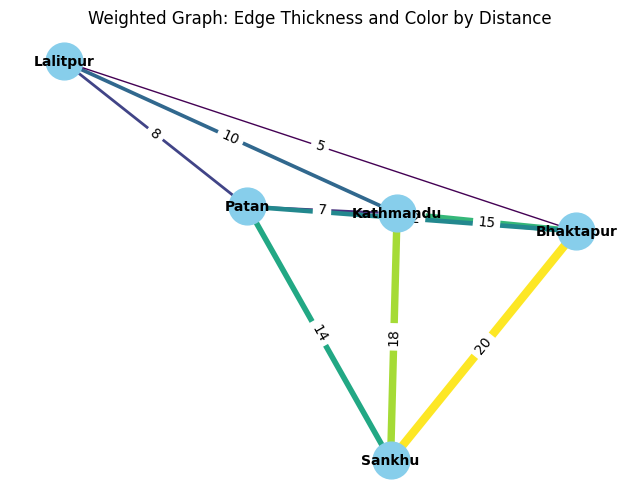

In [3]:
import matplotlib.cm as cm
import numpy as np

weights = np.array([G_undirected[u][v]['weight'] for u,v in G_undirected.edges()])

# Normalize weights for edge thickness and color intensity
max_wt = weights.max()
min_wt = weights.min()
norm_weights = (weights - min_wt) / (max_wt - min_wt)

plt.figure(figsize=(8,6))

# Nodes
nx.draw_networkx_nodes(G_undirected, pos, node_color='skyblue', node_size=700)
nx.draw_networkx_labels(G_undirected, pos, font_size=10, font_weight='bold')

# Edges with varying thickness and color
edges = G_undirected.edges()
colors = cm.viridis(norm_weights)
widths = 1 + 5 * norm_weights  # thickness from 1 to 6

for i, (edge, color, width) in enumerate(zip(edges, colors, widths)):
    nx.draw_networkx_edges(G_undirected, pos, edgelist=[edge], width=width, edge_color=[color])

# Edge labels with exact weights
nx.draw_networkx_edge_labels(G_undirected, pos, edge_labels=edge_labels, font_color='black')

plt.title("Weighted Graph: Edge Thickness and Color by Distance")
plt.axis('off')
plt.show()


Dataset: Same undirected city road network.

Features: Edge thickness and color intensity show the distance weight (thicker and darker edges = longer distance).

Observation: The road between Bhaktapur and Sankhu (20 km) is the thickest and darkest edge, indicating longest distance.

4. Algorithm Implementation: Kruskal’s Minimum Spanning Tree 

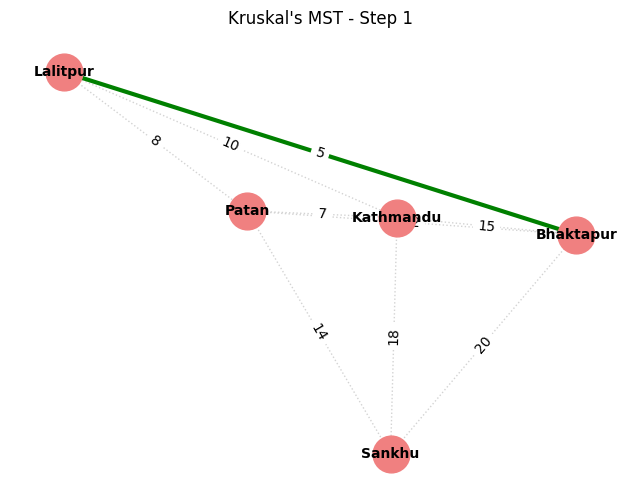

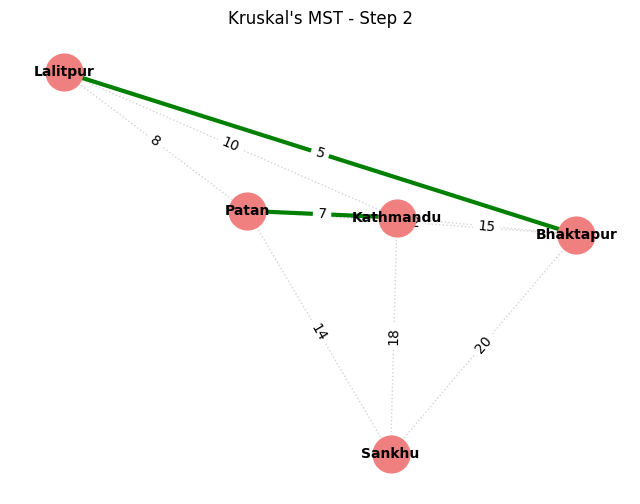

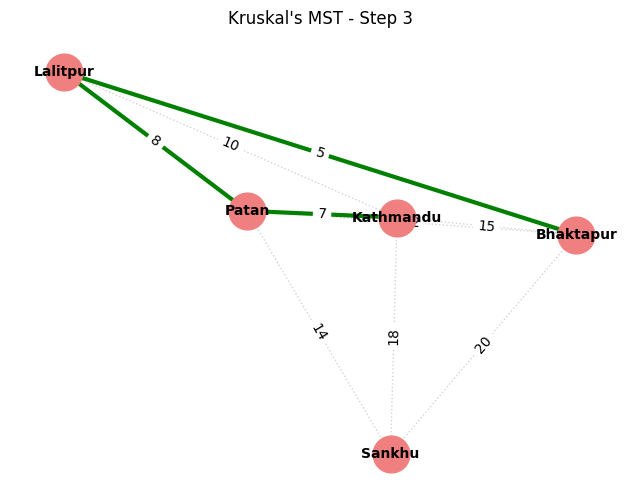

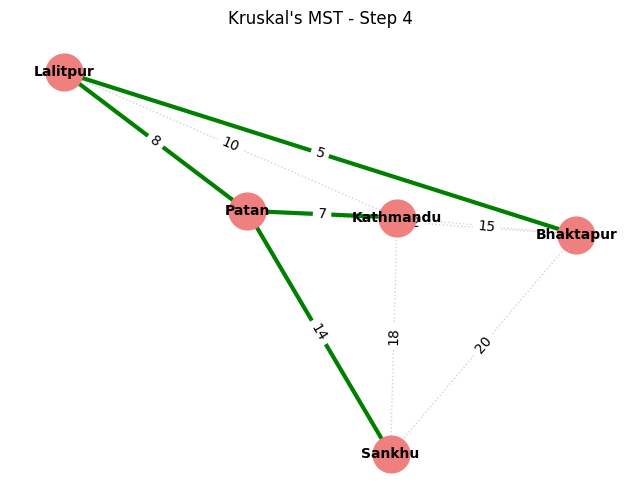

In [4]:
# Helper function to draw MST at each step
def draw_mst_step(graph, mst_edges, pos, step):
    plt.figure(figsize=(8,6))
    nx.draw_networkx_nodes(graph, pos, node_color='lightcoral', node_size=700)
    nx.draw_networkx_labels(graph, pos, font_size=10, font_weight='bold')

    # Draw all edges in light gray
    nx.draw_networkx_edges(graph, pos, edge_color='lightgray', style='dotted')

    # Highlight MST edges added so far
    if mst_edges:
        nx.draw_networkx_edges(graph, pos, edgelist=mst_edges, edge_color='green', width=3)
    
    # Edge labels (weights)
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_color='black')
    
    plt.title(f"Kruskal's MST - Step {step}")
    plt.axis('off')
    plt.show()

# Kruskal's MST implementation
def kruskal_mst(graph):
    parent = {}
    rank = {}

    def find(u):
        while parent[u] != u:
            parent[u] = parent[parent[u]]
            u = parent[u]
        return u
    
    def union(u, v):
        root_u = find(u)
        root_v = find(v)
        if root_u == root_v:
            return False
        if rank[root_u] < rank[root_v]:
            parent[root_u] = root_v
        else:
            parent[root_v] = root_u
            if rank[root_u] == rank[root_v]:
                rank[root_u] += 1
        return True

    # Initialize disjoint set
    for node in graph.nodes():
        parent[node] = node
        rank[node] = 0

    # Sort edges by weight
    edges_sorted = sorted(graph.edges(data=True), key=lambda x: x[2]['weight'])
    mst_edges = []
    step = 0

    for u, v, data in edges_sorted:
        if union(u, v):
            mst_edges.append((u, v))
            step += 1
            draw_mst_step(graph, mst_edges, pos, step)
            if len(mst_edges) == len(graph.nodes()) - 1:
                break
    
    return mst_edges

mst = kruskal_mst(G_undirected)


Final MST Visualization (highlight only MST edges)

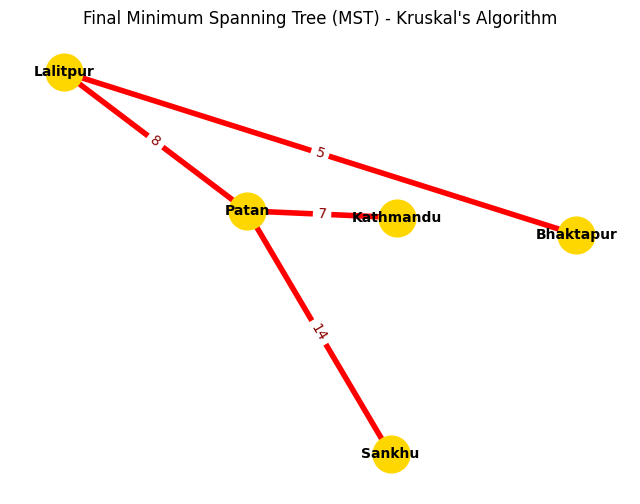

In [5]:
plt.figure(figsize=(8,6))
nx.draw_networkx_nodes(G_undirected, pos, node_color='gold', node_size=700)
nx.draw_networkx_labels(G_undirected, pos, font_size=10, font_weight='bold')

# Draw only MST edges
nx.draw_networkx_edges(G_undirected, pos, edgelist=mst, edge_color='red', width=4)

# Edge labels only for MST edges
mst_edge_labels = {edge: G_undirected.edges[edge]['weight'] for edge in mst}
nx.draw_networkx_edge_labels(G_undirected, pos, edge_labels=mst_edge_labels, font_color='darkred')

plt.title("Final Minimum Spanning Tree (MST) - Kruskal's Algorithm")
plt.axis('off')
plt.show()


Algorithm: Kruskal’s MST finds a subset of edges connecting all cities with minimum total distance, no cycles.

Steps: Each step shows MST growth by adding the smallest edge that doesn’t form a cycle.

Final MST: The network connects all cities with minimum total road distance.

Insight: MST can help plan minimum road construction or efficient routing infrastructure